In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
DATA_PATH = "data/PhiUSIIL_Phishing_URL_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (235795, 56)


In [10]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [12]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 235795
Number of columns: 56


In [13]:
print(df["label"].value_counts())

print("\nPercentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

label
1    134850
0    100945
Name: count, dtype: int64

Percentage:
label
1    57.19
0    42.81
Name: proportion, dtype: float64


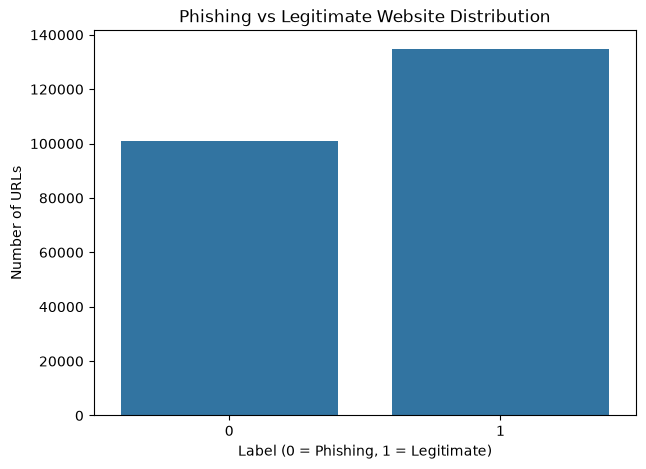

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Phishing vs Legitimate Website Distribution")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("Number of URLs")

plt.show()

In [15]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


In [16]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate URLs:", df["URL"].duplicated().sum())

Duplicate rows: 0
Duplicate URLs: 425


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,1.000000e+02
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [18]:
important_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "URLSimilarityIndex",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "IsHTTPS",
    "HasTitle"
]

feature_comparison = df.groupby("label")[important_features].mean().T

feature_comparison.columns = [
    "Phishing (0)",
    "Legitimate (1)"
]

feature_comparison

,Phishing (0),Legitimate (1)
URLLength,45.720293,26.228610
DomainLength,24.465144,19.228610
IsDomainIP,0.006320,0.000000
URLSimilarityIndex,49.616973,100.000000
NoOfSubDomain,1.168894,1.161661
HasObfuscation,0.004805,0.000000
NoOfLettersInURL,28.106583,12.933059
NoOfDegitsInURL,4.326217,0.050597
IsHTTPS,0.492238,1.000000
HasTitle,0.677587,0.998754


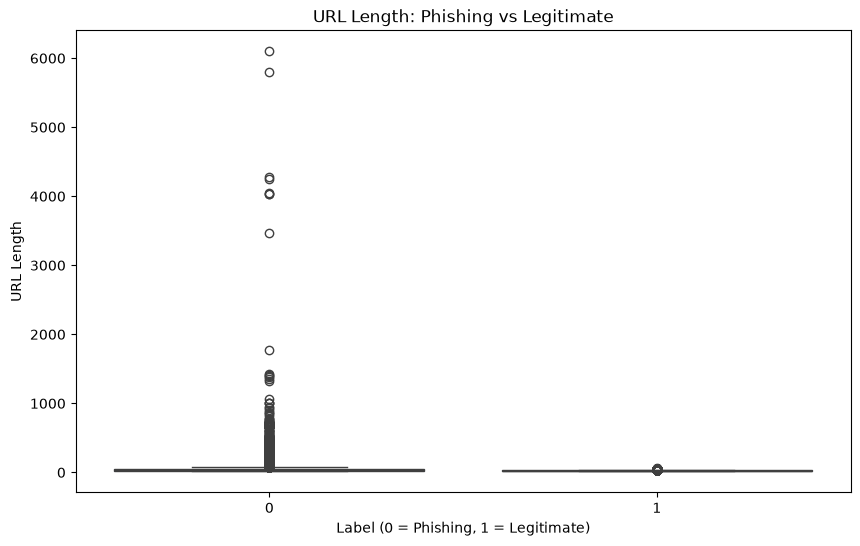

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="label",
    y="URLLength"
)

plt.title("URL Length: Phishing vs Legitimate")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URL Length")

plt.show()

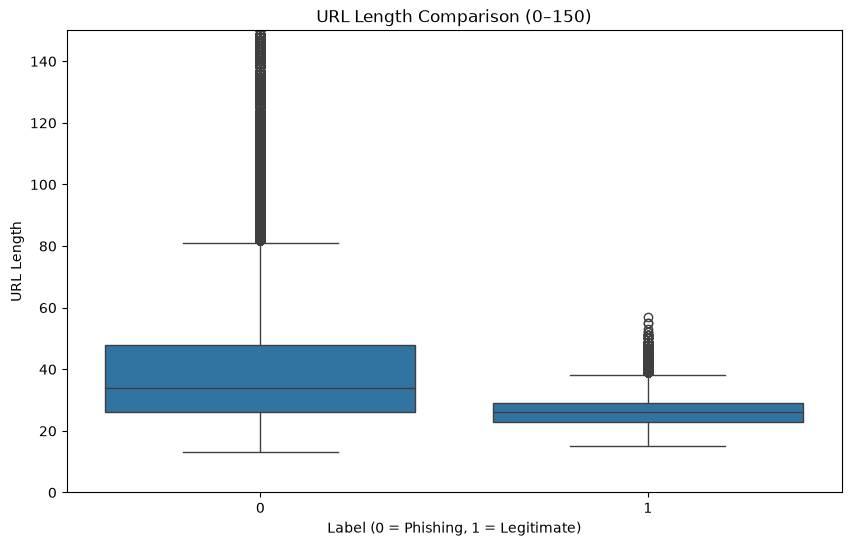

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="label",
    y="URLLength"
)

plt.ylim(0, 150)

plt.title("URL Length Comparison (0–150)")
plt.xlabel("Label (0 = Phishing, 1 = Legitimate)")
plt.ylabel("URL Length")

plt.show()

In [21]:
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical features:", len(numeric_features))
print("\nNumerical features:")
print(numeric_features.tolist())

Number of numerical features: 51

Numerical features:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [22]:
# Correlation with target variable
correlation_with_label = (
    df[numeric_features]
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print("Feature correlation with label:")
print(correlation_with_label)

Feature correlation with label:
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
SpacialCharRatioInURL        -0.533537
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
DegitRatioInURL              -0.432032
Robots                        0.392620
NoOfJS                        0.373500
LetterRatioInURL             -0.367794
Pay                           0.359747
NoOfOtherSpecialCharsInURL   -0.358891
NoOfSelfRef                   0.316211
DomainLength                 -0.283152
NoOfImage                     0.274658
LineOfCode                    0.

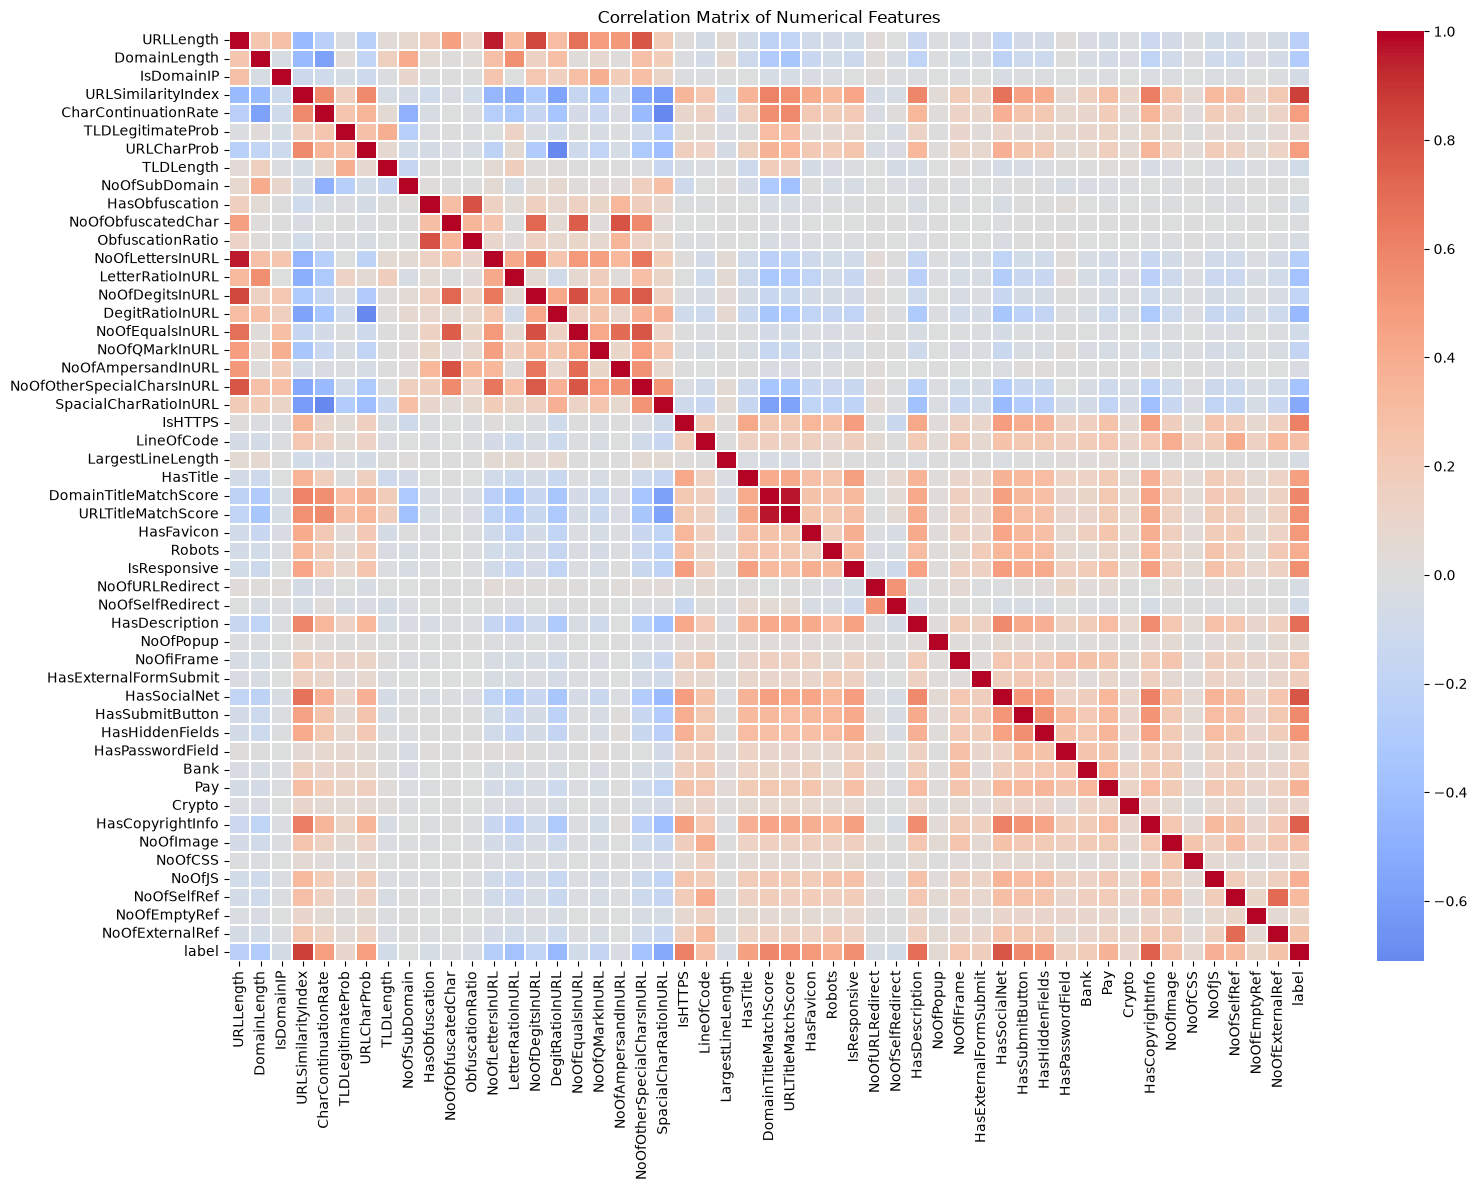

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 12))

correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [24]:
# Find highly correlated feature pairs
corr_matrix = df[numeric_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.80]

print("Highly correlated feature pairs (|r| >= 0.80):")
print(high_corr_pairs)

Highly correlated feature pairs (|r| >= 0.80):
DomainTitleMatchScore  URLTitleMatchScore    0.961008
URLLength              NoOfLettersInURL      0.956047
URLSimilarityIndex     label                 0.860358
URLLength              NoOfDegitsInURL       0.835809
NoOfDegitsInURL        NoOfEqualsInURL       0.806024
dtype: float64


In [25]:
# Exclude target variable from feature-to-feature correlation analysis

feature_columns = numeric_features.drop("label")

corr_matrix = df[feature_columns].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.80]

print("Highly correlated feature pairs (|r| >= 0.80):")
print(high_corr_pairs)

Highly correlated feature pairs (|r| >= 0.80):
DomainTitleMatchScore  URLTitleMatchScore    0.961008
URLLength              NoOfLettersInURL      0.956047
                       NoOfDegitsInURL       0.835809
NoOfDegitsInURL        NoOfEqualsInURL       0.806024
dtype: float64


In [26]:
feature_analysis = pd.DataFrame({
    "Feature": correlation_with_label.index,
    "Target_Correlation": correlation_with_label.values,
    "Absolute_Correlation": correlation_with_label.abs().values
})

feature_analysis = feature_analysis.sort_values(
    "Absolute_Correlation",
    ascending=False
).reset_index(drop=True)

feature_analysis

,Feature,Target_Correlation,Absolute_Correlation
0,URLSimilarityIndex,0.860358,0.860358
1,HasSocialNet,0.784255,0.784255
2,HasCopyrightInfo,0.743358,0.743358
3,HasDescription,0.690232,0.690232
4,IsHTTPS,0.609132,0.609132
5,DomainTitleMatchScore,0.584905,0.584905
6,HasSubmitButton,0.578561,0.578561
7,IsResponsive,0.548608,0.548608
8,URLTitleMatchScore,0.539419,0.539419
9,SpacialCharRatioInURL,-0.533537,0.533537


In [27]:
url_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLD",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS",
    "URLSimilarityIndex",
    "CharContinuationRate",
    "TLDLegitimateProb",
    "URLCharProb"
]

print("URL-related features:", len(url_features))
print(url_features)

URL-related features: 23
['URLLength', 'DomainLength', 'IsDomainIP', 'TLD', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb']


In [28]:
page_features = [
    "LineOfCode",
    "LargestLineLength",
    "HasTitle",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "HasFavicon",
    "Robots",
    "IsResponsive",
    "NoOfURLRedirect",
    "NoOfSelfRedirect",
    "HasDescription",
    "NoOfPopup",
    "NoOfiFrame",
    "HasExternalFormSubmit",
    "HasSocialNet",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasPasswordField",
    "Bank",
    "Pay",
    "Crypto",
    "HasCopyrightInfo",
    "NoOfImage",
    "NoOfCSS",
    "NoOfJS",
    "NoOfSelfRef",
    "NoOfEmptyRef",
    "NoOfExternalRef"
]

print("Page-related features:", len(page_features))
print(page_features)

Page-related features: 28
['LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [29]:
print("Number of unique TLDs:", df["TLD"].nunique())

print("\nTop 20 TLDs:")
print(df["TLD"].value_counts().head(20))

Number of unique TLDs: 695

Top 20 TLDs:
TLD
com     112554
org      18793
net       7097
app       6508
uk        6395
co        5422
io        4201
de        3996
ru        3875
au        2979
dev       2345
top       2329
jp        2219
it        1887
edu       1861
fr        1858
br        1846
nl        1727
ca        1614
info      1566
Name: count, dtype: int64


In [30]:
print("Raw text columns:")
print(df[["FILENAME", "URL", "Domain", "TLD", "Title"]].dtypes)

Raw text columns:
FILENAME    str
URL         str
Domain      str
TLD         str
Title       str
dtype: object


In [31]:
url_numeric_features = [
    col for col in url_features
    if col != "TLD"
]

feature_variance = df[url_numeric_features].nunique().sort_values()

print("URL features with lowest number of unique values:")
print(feature_variance.head(15))

URL features with lowest number of unique values:
IsDomainIP                      2
HasObfuscation                  2
IsHTTPS                         2
NoOfQMarkInURL                  5
NoOfSubDomain                  10
TLDLength                      12
NoOfObfuscatedChar             20
NoOfEqualsInURL                25
NoOfAmpersandInURL             31
NoOfOtherSpecialCharsInURL     74
DomainLength                  101
ObfuscationRatio              146
NoOfDegitsInURL               182
SpacialCharRatioInURL         240
NoOfLettersInURL              421
dtype: int64


In [32]:
# Check correlation between URL-based numerical features

url_numeric_features = [
    col for col in url_features
    if col != "TLD"
]

url_corr = df[url_numeric_features].corr()

# Find highly correlated feature pairs
high_corr_pairs = []

for i in range(len(url_corr.columns)):
    for j in range(i + 1, len(url_corr.columns)):
        corr_value = url_corr.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_corr_pairs.append(
                (
                    url_corr.columns[i],
                    url_corr.columns[j],
                    corr_value
                )
            )

high_corr_pairs = sorted(
    high_corr_pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

print("Highly correlated URL feature pairs (|correlation| >= 0.80):")

for feature1, feature2, correlation in high_corr_pairs:
    print(f"{feature1} <-> {feature2}: {correlation:.3f}")

Highly correlated URL feature pairs (|correlation| >= 0.80):
URLLength <-> NoOfLettersInURL: 0.956
URLLength <-> NoOfDegitsInURL: 0.836
NoOfDegitsInURL <-> NoOfEqualsInURL: 0.806


In [33]:
# Correlation of URL features with target

url_target_corr = (
    df[url_numeric_features + ["label"]]
    .corr()["label"]
    .drop("label")
    .sort_values(key=abs, ascending=False)
)

print("URL features ranked by absolute correlation with label:")
print(url_target_corr)

URL features ranked by absolute correlation with label:
URLSimilarityIndex            0.860358
IsHTTPS                       0.609132
SpacialCharRatioInURL        -0.533537
URLCharProb                   0.469749
CharContinuationRate          0.467735
DegitRatioInURL              -0.432032
LetterRatioInURL             -0.367794
NoOfOtherSpecialCharsInURL   -0.358891
DomainLength                 -0.283152
NoOfLettersInURL             -0.258090
URLLength                    -0.233445
NoOfDegitsInURL              -0.177980
NoOfQMarkInURL               -0.175621
TLDLegitimateProb             0.097389
TLDLength                    -0.079159
NoOfEqualsInURL              -0.076963
IsDomainIP                   -0.060202
HasObfuscation               -0.052473
ObfuscationRatio             -0.041915
NoOfAmpersandInURL           -0.034622
NoOfObfuscatedChar           -0.015315
NoOfSubDomain                -0.005955
Name: label, dtype: float64


In [34]:
# Show sample URLs with important URL-based features

url_sample_columns = [
    "URL",
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "NoOfSubDomain",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfQMarkInURL",
    "IsHTTPS",
    "URLSimilarityIndex",
    "label"
]

display(df[url_sample_columns].head(10))

,URL,URLLength,DomainLength,IsDomainIP,NoOfSubDomain,NoOfLettersInURL,NoOfDegitsInURL,NoOfQMarkInURL,IsHTTPS,URLSimilarityIndex,label
0,https://www.southbankmosaics.com,31,24,0,1,18,0,0,1,100.0,1
1,https://www.uni-mainz.de,23,16,0,1,9,0,0,1,100.0,1
2,https://www.voicefmradio.co.uk,29,22,0,2,15,0,0,1,100.0,1
3,https://www.sfnmjournal.com,26,19,0,1,13,0,0,1,100.0,1
4,https://www.rewildingargentina.org,33,26,0,1,20,0,0,1,100.0,1
5,https://www.globalreporting.org,30,23,0,1,17,0,0,1,100.0,1
6,https://www.saffronart.com,25,18,0,1,12,0,0,1,100.0,1
7,https://www.nerdscandy.com,25,18,0,1,12,0,0,1,100.0,1
8,https://www.hyderabadonline.in,29,22,0,1,16,0,0,1,100.0,1
9,https://www.aap.org,18,11,0,1,5,0,0,1,100.0,1


In [35]:
from urllib.parse import urlparse
import re
import ipaddress


def extract_url_features(url):
    """
    Extract URL-based features from a raw URL.
    """

    # Make sure URL has a scheme
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        url = "http://" + url

    parsed = urlparse(url)

    domain = parsed.netloc.split("@")[-1].split(":")[0]
    path = parsed.path
    query = parsed.query

    # Remove scheme for URL character analysis
    url_without_scheme = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        "",
        url
    )

    # Check whether domain is an IP address
    is_domain_ip = 0

    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    # Basic URL components
    url_length = len(url)
    domain_length = len(domain)

    no_of_subdomain = max(
        len(domain.split(".")) - 2,
        0
    )

    # Character counts
    no_of_letters = sum(c.isalpha() for c in url)
    no_of_digits = sum(c.isdigit() for c in url)

    no_of_qmark = url.count("?")
    no_of_equals = url.count("=")
    no_of_ampersand = url.count("&")

    special_chars = re.findall(
        r"[^a-zA-Z0-9]",
        url_without_scheme
    )

    no_of_other_special_chars = len(special_chars)

    # HTTPS
    is_https = int(parsed.scheme.lower() == "https")

    # Ratios
    letter_ratio = no_of_letters / url_length if url_length else 0
    digit_ratio = no_of_digits / url_length if url_length else 0

    special_char_ratio = (
        no_of_other_special_chars / len(url_without_scheme)
        if url_without_scheme
        else 0
    )

    # Obfuscation-related features
    obfuscated_chars = re.findall(
        r"%[0-9a-fA-F]{2}",
        url
    )

    no_of_obfuscated_char = len(obfuscated_chars)

    has_obfuscation = int(no_of_obfuscated_char > 0)

    obfuscation_ratio = (
        no_of_obfuscated_char / url_length
        if url_length
        else 0
    )

    # TLD
    tld = ""

    if "." in domain:
        tld = domain.split(".")[-1].lower()

    tld_length = len(tld)

    return {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": is_domain_ip,
        "TLD": tld,
        "TLDLength": tld_length,
        "NoOfSubDomain": no_of_subdomain,
        "HasObfuscation": has_obfuscation,
        "NoOfObfuscatedChar": no_of_obfuscated_char,
        "ObfuscationRatio": obfuscation_ratio,
        "NoOfLettersInURL": no_of_letters,
        "LetterRatioInURL": letter_ratio,
        "NoOfDegitsInURL": no_of_digits,
        "DegitRatioInURL": digit_ratio,
        "NoOfEqualsInURL": no_of_equals,
        "NoOfQMarkInURL": no_of_qmark,
        "NoOfAmpersandInURL": no_of_ampersand,
        "NoOfOtherSpecialCharsInURL": no_of_other_special_chars,
        "SpacialCharRatioInURL": special_char_ratio,
        "IsHTTPS": is_https,
    }

In [36]:
test_url = "https://www.google.com/search?q=python"

test_features = extract_url_features(test_url)

test_features

{'URLLength': 38,
 'DomainLength': 14,
 'IsDomainIP': 0,
 'TLD': 'com',
 'TLDLength': 3,
 'NoOfSubDomain': 1,
 'HasObfuscation': 0,
 'NoOfObfuscatedChar': 0,
 'ObfuscationRatio': 0.0,
 'NoOfLettersInURL': 30,
 'LetterRatioInURL': 0.7894736842105263,
 'NoOfDegitsInURL': 0,
 'DegitRatioInURL': 0.0,
 'NoOfEqualsInURL': 1,
 'NoOfQMarkInURL': 1,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 5,
 'SpacialCharRatioInURL': 0.16666666666666666,
 'IsHTTPS': 1}

In [37]:
import pandas as pd

df = pd.read_csv("data/PhiUSIIL_Phishing_URL_Dataset.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (235795, 56)


In [38]:
sample_row = df.iloc[0]

sample_url = sample_row["URL"]

our_features = extract_url_features(sample_url)

comparison_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "NoOfDegitsInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "IsHTTPS"
]

comparison = []

for feature in comparison_features:
    comparison.append({
        "Feature": feature,
        "Dataset Value": sample_row[feature],
        "Our Extractor": our_features[feature]
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Feature,Dataset Value,Our Extractor
0,URLLength,31.0,32.0
1,DomainLength,24.0,24.0
2,IsDomainIP,0.0,0.0
3,TLDLength,3.0,3.0
4,NoOfSubDomain,1.0,1.0
5,HasObfuscation,0.0,0.0
6,NoOfObfuscatedChar,0.0,0.0
7,ObfuscationRatio,0.0,0.0
8,NoOfLettersInURL,18.0,27.0
9,NoOfDegitsInURL,0.0,0.0


In [39]:
# Final candidate URL-only features

url_model_features = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "TLDLength",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]

print("Number of URL-only candidate features:", len(url_model_features))
print("\nFeatures:")
for i, feature in enumerate(url_model_features, 1):
    print(f"{i}. {feature}")

Number of URL-only candidate features: 18

Features:
1. URLLength
2. DomainLength
3. IsDomainIP
4. TLDLength
5. NoOfSubDomain
6. HasObfuscation
7. NoOfObfuscatedChar
8. ObfuscationRatio
9. NoOfLettersInURL
10. LetterRatioInURL
11. NoOfDegitsInURL
12. DegitRatioInURL
13. NoOfEqualsInURL
14. NoOfQMarkInURL
15. NoOfAmpersandInURL
16. NoOfOtherSpecialCharsInURL
17. SpacialCharRatioInURL
18. IsHTTPS


In [40]:
# Create feature matrix (X) and target vector (y)

X = df[url_model_features].copy()
y = df["label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (235795, 18)
y shape: (235795,)

Target distribution:
label
1    134850
0    100945
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set:
X_train: (188636, 18)
y_train: (188636,)

Testing set:
X_test: (47159, 18)
y_test: (47159,)

Training target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Testing target distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [42]:
from sklearn.ensemble import RandomForestClassifier

# Create baseline Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [43]:
# Make predictions on unseen test data

y_pred = rf_model.predict(X_test)

print("Prediction completed successfully.")
print("Number of predictions:", len(y_pred))

Prediction completed successfully.
Number of predictions: 47159


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Phishing", "Legitimate"]
))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Model Evaluation
Accuracy : 0.9973
Precision: 0.9959
Recall   : 0.9994
F1-Score : 0.9976

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Confusion Matrix:
[[20077   112]
 [   17 26953]]


In [45]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
17,IsHTTPS,3.925970e-01
15,NoOfOtherSpecialCharsInURL,1.420077e-01
10,NoOfDegitsInURL,8.979214e-02
9,LetterRatioInURL,7.195386e-02
11,DegitRatioInURL,6.599323e-02
0,URLLength,6.092205e-02
16,SpacialCharRatioInURL,5.975319e-02
8,NoOfLettersInURL,4.630695e-02
4,NoOfSubDomain,3.680652e-02
1,DomainLength,2.470925e-02


In [46]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("5-Fold Cross-Validation Accuracy:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

5-Fold Cross-Validation Accuracy:
Fold 1: 0.9976
Fold 2: 0.9973
Fold 3: 0.9976
Fold 4: 0.9976
Fold 5: 0.9976

Mean Accuracy: 0.9975
Std Deviation: 0.0001


In [47]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

hgb_model.fit(X_train, y_train)

print("HistGradientBoosting training completed successfully.")

HistGradientBoosting training completed successfully.


In [48]:
# Predictions from HistGradientBoosting

hgb_pred = hgb_model.predict(X_test)

print("Prediction completed successfully.")
print("Number of predictions:", len(hgb_pred))

Prediction completed successfully.
Number of predictions: 47159


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate metrics
hgb_accuracy = accuracy_score(y_test, hgb_pred)
hgb_precision = precision_score(y_test, hgb_pred)
hgb_recall = recall_score(y_test, hgb_pred)
hgb_f1 = f1_score(y_test, hgb_pred)

print("HistGradientBoosting Evaluation")
print("=" * 45)

print(f"Accuracy : {hgb_accuracy:.4f}")
print(f"Precision: {hgb_precision:.4f}")
print(f"Recall   : {hgb_recall:.4f}")
print(f"F1-Score : {hgb_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    hgb_pred,
    target_names=["Phishing", "Legitimate"]
))

print("Confusion Matrix:")
hgb_cm = confusion_matrix(y_test, hgb_pred)
print(hgb_cm)

HistGradientBoosting Evaluation
Accuracy : 0.9974
Precision: 0.9959
Recall   : 0.9996
F1-Score : 0.9977

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Confusion Matrix:
[[20077   112]
 [   10 26960]]


In [50]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

hgb_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

hgb_cv_scores = cross_val_score(
    hgb_model,
    X,
    y,
    cv=hgb_cv,
    scoring="accuracy",
    n_jobs=-1
)

print("HistGradientBoosting 5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(hgb_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy: {hgb_cv_scores.mean():.4f}")
print(f"Std Deviation: {hgb_cv_scores.std():.4f}")

HistGradientBoosting 5-Fold Cross-Validation Accuracy:
Fold 1: 0.9978
Fold 2: 0.9977
Fold 3: 0.9979
Fold 4: 0.9978
Fold 5: 0.9977

Mean Accuracy: 0.9978
Std Deviation: 0.0001


In [51]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    hgb_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="accuracy",
    n_jobs=-1
)

hgb_feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_Std": perm_result.importances_std
})

hgb_feature_importance = hgb_feature_importance.sort_values(
    by="Importance_Mean",
    ascending=False
)

display(hgb_feature_importance)

,Feature,Importance_Mean,Importance_Std
9,LetterRatioInURL,0.252266,0.000544
1,DomainLength,0.223457,0.000654
17,IsHTTPS,0.215573,0.001068
0,URLLength,0.184287,0.000828
15,NoOfOtherSpecialCharsInURL,0.136699,0.000628
10,NoOfDegitsInURL,0.054798,0.000524
4,NoOfSubDomain,0.035344,0.000505
16,SpacialCharRatioInURL,0.020009,0.000625
11,DegitRatioInURL,0.005182,0.000383
8,NoOfLettersInURL,0.001277,0.000102


In [52]:
reduced_features = [
    "LetterRatioInURL",
    "DomainLength",
    "IsHTTPS",
    "URLLength",
    "NoOfOtherSpecialCharsInURL",
    "NoOfDegitsInURL",
    "NoOfSubDomain",
    "SpacialCharRatioInURL",
    "DegitRatioInURL"
]

print("Reduced feature count:", len(reduced_features))

Reduced feature count: 9


In [53]:
# Create reduced feature datasets

X_train_reduced = X_train[reduced_features]
X_test_reduced = X_test[reduced_features]

print("X_train_reduced:", X_train_reduced.shape)
print("X_test_reduced:", X_test_reduced.shape)

X_train_reduced: (188636, 9)
X_test_reduced: (47159, 9)


In [54]:
# Train HistGradientBoosting on reduced feature set

hgb_reduced_model = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

hgb_reduced_model.fit(
    X_train_reduced,
    y_train
)

print("Reduced-feature HGB training completed successfully.")

Reduced-feature HGB training completed successfully.


In [55]:
# Predictions from reduced-feature HGB

hgb_reduced_pred = hgb_reduced_model.predict(X_test_reduced)

print("Prediction completed successfully.")
print("Number of predictions:", len(hgb_reduced_pred))

Prediction completed successfully.
Number of predictions: 47159


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate metrics
reduced_accuracy = accuracy_score(y_test, hgb_reduced_pred)
reduced_precision = precision_score(y_test, hgb_reduced_pred)
reduced_recall = recall_score(y_test, hgb_reduced_pred)
reduced_f1 = f1_score(y_test, hgb_reduced_pred)

print("Reduced-feature HGB Evaluation")
print("=" * 45)

print(f"Accuracy : {reduced_accuracy:.4f}")
print(f"Precision: {reduced_precision:.4f}")
print(f"Recall   : {reduced_recall:.4f}")
print(f"F1-Score : {reduced_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    hgb_reduced_pred,
    target_names=["Phishing", "Legitimate"]
))

print("Confusion Matrix:")
reduced_cm = confusion_matrix(y_test, hgb_reduced_pred)
print(reduced_cm)

Reduced-feature HGB Evaluation
Accuracy : 0.9975
Precision: 0.9961
Recall   : 0.9996
F1-Score : 0.9979

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

Confusion Matrix:
[[20084   105]
 [   11 26959]]


In [57]:
# 5-Fold Cross-Validation for reduced-feature HGB

reduced_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

reduced_cv_scores = cross_val_score(
    hgb_reduced_model,
    X[reduced_features],
    y,
    cv=reduced_cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Reduced-feature HGB 5-Fold Cross-Validation Accuracy:")

for i, score in enumerate(reduced_cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print(f"\nMean Accuracy: {reduced_cv_scores.mean():.4f}")
print(f"Std Deviation: {reduced_cv_scores.std():.4f}")

Reduced-feature HGB 5-Fold Cross-Validation Accuracy:
Fold 1: 0.9976
Fold 2: 0.9978
Fold 3: 0.9979
Fold 4: 0.9979
Fold 5: 0.9977

Mean Accuracy: 0.9978
Std Deviation: 0.0001


In [58]:
# Check the 9 features produced by our URL extractor

test_url = "https://www.google.com/search?q=python"

test_features = extract_url_features(test_url)

for feature in reduced_features:
    print(f"{feature}: {test_features[feature]}")

LetterRatioInURL: 0.7894736842105263
DomainLength: 14
IsHTTPS: 1
URLLength: 38
NoOfOtherSpecialCharsInURL: 5
NoOfDegitsInURL: 0
NoOfSubDomain: 1
SpacialCharRatioInURL: 0.16666666666666666
DegitRatioInURL: 0.0


In [59]:
# Compare our extractor with dataset values on 100 URLs

validation_features = [
    "URLLength",
    "DomainLength",
    "IsHTTPS",
    "NoOfOtherSpecialCharsInURL",
    "NoOfDegitsInURL",
    "NoOfSubDomain",
    "SpacialCharRatioInURL",
    "DegitRatioInURL"
]

sample_df = df.sample(
    n=100,
    random_state=42
)

results = []

for _, row in sample_df.iterrows():

    extracted = extract_url_features(row["URL"])

    for feature in validation_features:
        results.append({
            "Feature": feature,
            "Dataset": row[feature],
            "Extracted": extracted[feature]
        })

validation_df = pd.DataFrame(results)

accuracy_by_feature = (
    validation_df
    .assign(
        Match=lambda x: (
            x["Dataset"].round(6) ==
            x["Extracted"].round(6)
        )
    )
    .groupby("Feature")["Match"]
    .mean()
    .sort_values()
)

print("Feature extraction match rate:")
display(accuracy_by_feature.to_frame("Match Rate"))

Feature extraction match rate:


,Match Rate
Feature,
SpacialCharRatioInURL,0.00
NoOfOtherSpecialCharsInURL,0.21
URLLength,0.24
DegitRatioInURL,0.76
DomainLength,1.00
IsHTTPS,1.00
NoOfDegitsInURL,1.00
NoOfSubDomain,1.00


In [60]:
# Diagnose how PhiUSIIL calculates URL-related values

sample_row = df.iloc[0]
url = sample_row["URL"]

print("RAW URL:")
print(repr(url))

print("\n--- Length checks ---")
print("Dataset URLLength:", sample_row["URLLength"])
print("len(URL):", len(url))
print("len(URL without http/https):",
      len(re.sub(r"^https?://", "", url, flags=re.IGNORECASE)))
print("len(URL without trailing slash):",
      len(url.rstrip("/")))

print("\n--- Letter count checks ---")
print("Dataset NoOfLettersInURL:", sample_row["NoOfLettersInURL"])
print("isalpha() on full URL:",
      sum(c.isalpha() for c in url))
print("isalpha() without scheme:",
      sum(c.isalpha() for c in re.sub(
          r"^https?://", "", url, flags=re.IGNORECASE
      )))

print("\n--- Special character checks ---")
print("Dataset NoOfOtherSpecialCharsInURL:",
      sample_row["NoOfOtherSpecialCharsInURL"])

special_full = sum(
    not c.isalnum()
    for c in url
)

special_without_scheme = sum(
    not c.isalnum()
    for c in re.sub(
        r"^https?://", "", url, flags=re.IGNORECASE
    )
)

print("Special chars - full URL:", special_full)
print("Special chars - without scheme:", special_without_scheme)

print("\n--- Digit ratio checks ---")
digits = sum(c.isdigit() for c in url)

print("Dataset DegitRatioInURL:",
      sample_row["DegitRatioInURL"])

print("digits / full URL length:",
      digits / len(url) if len(url) else 0)

url_no_scheme = re.sub(
    r"^https?://", "", url, flags=re.IGNORECASE
)

print("digits / URL without scheme length:",
      digits / len(url_no_scheme) if len(url_no_scheme) else 0)

RAW URL:
'https://www.southbankmosaics.com'

--- Length checks ---
Dataset URLLength: 31
len(URL): 32
len(URL without http/https): 24
len(URL without trailing slash): 32

--- Letter count checks ---
Dataset NoOfLettersInURL: 18
isalpha() on full URL: 27
isalpha() without scheme: 22

--- Special character checks ---
Dataset NoOfOtherSpecialCharsInURL: 1
Special chars - full URL: 5
Special chars - without scheme: 2

--- Digit ratio checks ---
Dataset DegitRatioInURL: 0.0
digits / full URL length: 0.0
digits / URL without scheme length: 0.0


In [61]:
sample_url = df.iloc[0]["URL"]

print("repr(URL):", repr(sample_url))
print("Length:", len(sample_url))

print("\nCharacters with index:")
for i, ch in enumerate(sample_url):
    print(i, repr(ch))

repr(URL): 'https://www.southbankmosaics.com'
Length: 32

Characters with index:
0 'h'
1 't'
2 't'
3 'p'
4 's'
5 ':'
6 '/'
7 '/'
8 'w'
9 'w'
10 'w'
11 '.'
12 's'
13 'o'
14 'u'
15 't'
16 'h'
17 'b'
18 'a'
19 'n'
20 'k'
21 'm'
22 'o'
23 's'
24 'a'
25 'i'
26 'c'
27 's'
28 '.'
29 'c'
30 'o'
31 'm'


In [62]:
sample = df.iloc[0]

print("URL       :", repr(sample["URL"]))
print("Domain    :", repr(sample["Domain"]))
print("TLD       :", repr(sample["TLD"]))
print("URLLength :", sample["URLLength"])
print("Letters   :", sample["NoOfLettersInURL"])
print("Special   :", sample["NoOfOtherSpecialCharsInURL"])

print("\n--- Domain character analysis ---")
for i, ch in enumerate(sample["Domain"]):
    print(i, repr(ch))

URL       : 'https://www.southbankmosaics.com'
Domain    : 'www.southbankmosaics.com'
TLD       : 'com'
URLLength : 31
Letters   : 18
Special   : 1

--- Domain character analysis ---
0 'w'
1 'w'
2 'w'
3 '.'
4 's'
5 'o'
6 'u'
7 't'
8 'h'
9 'b'
10 'a'
11 'n'
12 'k'
13 'm'
14 'o'
15 's'
16 'a'
17 'i'
18 'c'
19 's'
20 '.'
21 'c'
22 'o'
23 'm'


In [63]:
import re
import ipaddress
from urllib.parse import urlparse


CUSTOM_URL_FEATURES = [
    "URLLength",
    "DomainLength",
    "IsDomainIP",
    "NoOfSubDomain",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "NoOfLettersInURL",
    "LetterRatioInURL",
    "NoOfDegitsInURL",
    "DegitRatioInURL",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL",
    "SpacialCharRatioInURL",
    "IsHTTPS"
]


def extract_custom_url_features(url):
    if not isinstance(url, str):
        url = str(url)

    url = url.strip()

    # Add scheme if missing
    if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
        url = "http://" + url

    parsed = urlparse(url)

    # Extract domain
    domain = parsed.netloc.split("@")[-1].split(":")[0]

    # URL without scheme
    url_without_scheme = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        "",
        url
    )

    # Domain is IP?
    try:
        ipaddress.ip_address(domain)
        is_domain_ip = 1
    except ValueError:
        is_domain_ip = 0

    # Basic counts
    url_length = len(url)
    domain_length = len(domain)

    no_of_subdomain = max(len(domain.split(".")) - 2, 0)

    no_of_letters = sum(c.isalpha() for c in url)
    no_of_digits = sum(c.isdigit() for c in url)

    no_of_equals = url.count("=")
    no_of_qmark = url.count("?")
    no_of_ampersand = url.count("&")

    # Special characters
    special_chars = re.findall(
        r"[^a-zA-Z0-9]",
        url_without_scheme
    )

    no_of_other_special_chars = len(special_chars)

    # Ratios
    letter_ratio = (
        no_of_letters / url_length
        if url_length else 0
    )

    digit_ratio = (
        no_of_digits / url_length
        if url_length else 0
    )

    special_char_ratio = (
        no_of_other_special_chars / len(url_without_scheme)
        if url_without_scheme else 0
    )

    # Obfuscation
    obfuscated_chars = re.findall(
        r"%[0-9a-fA-F]{2}",
        url
    )

    no_of_obfuscated_char = len(obfuscated_chars)

    has_obfuscation = int(
        no_of_obfuscated_char > 0
    )

    obfuscation_ratio = (
        no_of_obfuscated_char / url_length
        if url_length else 0
    )

    # HTTPS
    is_https = int(
        parsed.scheme.lower() == "https"
    )

    return {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": is_domain_ip,
        "NoOfSubDomain": no_of_subdomain,
        "HasObfuscation": has_obfuscation,
        "NoOfObfuscatedChar": no_of_obfuscated_char,
        "ObfuscationRatio": obfuscation_ratio,
        "NoOfLettersInURL": no_of_letters,
        "LetterRatioInURL": letter_ratio,
        "NoOfDegitsInURL": no_of_digits,
        "DegitRatioInURL": digit_ratio,
        "NoOfEqualsInURL": no_of_equals,
        "NoOfQMarkInURL": no_of_qmark,
        "NoOfAmpersandInURL": no_of_ampersand,
        "NoOfOtherSpecialCharsInURL": no_of_other_special_chars,
        "SpacialCharRatioInURL": special_char_ratio,
        "IsHTTPS": is_https
    }

In [64]:
test_url = "https://www.google.com/search?q=python"

test_features = extract_custom_url_features(test_url)

test_features

{'URLLength': 38,
 'DomainLength': 14,
 'IsDomainIP': 0,
 'NoOfSubDomain': 1,
 'HasObfuscation': 0,
 'NoOfObfuscatedChar': 0,
 'ObfuscationRatio': 0.0,
 'NoOfLettersInURL': 30,
 'LetterRatioInURL': 0.7894736842105263,
 'NoOfDegitsInURL': 0,
 'DegitRatioInURL': 0.0,
 'NoOfEqualsInURL': 1,
 'NoOfQMarkInURL': 1,
 'NoOfAmpersandInURL': 0,
 'NoOfOtherSpecialCharsInURL': 5,
 'SpacialCharRatioInURL': 0.16666666666666666,
 'IsHTTPS': 1}

In [65]:
import numpy as np

sample_100 = df["URL"].sample(
    100,
    random_state=42
)

results = []

for url in sample_100:
    try:
        features = extract_custom_url_features(url)
        results.append(features)
    except Exception as e:
        results.append({"ERROR": str(e)})

results_df = pd.DataFrame(results)

print("Rows processed:", len(results_df))
print("Expected rows:", 100)
print("Errors:", results_df.isna().all(axis=1).sum())

print("\nFeature shape:", results_df.shape)
print("\nMissing values:")
print(results_df.isnull().sum())

print("\nFirst 5 extracted rows:")
display(results_df.head())

Rows processed: 100
Expected rows: 100
Errors: 0

Feature shape: (100, 17)

Missing values:
URLLength                     0
DomainLength                  0
IsDomainIP                    0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
dtype: int64

First 5 extracted rows:


,URLLength,DomainLength,IsDomainIP,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS
0,25,17,0,2,0,0,0.0,19,0.760000,0,0.000000,0,0,0,3,0.176471,1
1,60,28,0,0,0,0,0.0,51,0.850000,1,0.016667,0,0,0,5,0.096154,1
2,385,27,0,3,0,0,0.0,307,0.797403,51,0.132468,0,0,0,24,0.063660,1
3,19,6,0,0,0,0,0.0,12,0.631579,2,0.105263,0,0,0,2,0.166667,0
4,36,28,0,2,0,0,0.0,30,0.833333,0,0.000000,0,0,0,3,0.107143,1


In [66]:
# Extract custom features for the complete dataset

custom_features = []

for url in df["URL"]:
    custom_features.append(
        extract_custom_url_features(url)
    )

custom_features_df = pd.DataFrame(custom_features)

print("Shape:", custom_features_df.shape)

print("\nMinimum values:")
display(custom_features_df.min())

print("\nMaximum values:")
display(custom_features_df.max())

print("\nAny negative values:")
print((custom_features_df < 0).any().any())

print("\nAny missing values:")
print(custom_features_df.isnull().sum().sum())

Shape: (235795, 17)

Minimum values:


URLLength                     14.000000
DomainLength                   4.000000
IsDomainIP                     0.000000
NoOfSubDomain                  0.000000
HasObfuscation                 0.000000
NoOfObfuscatedChar             0.000000
ObfuscationRatio               0.000000
NoOfLettersInURL               4.000000
LetterRatioInURL               0.142857
NoOfDegitsInURL                0.000000
DegitRatioInURL                0.000000
NoOfEqualsInURL                0.000000
NoOfQMarkInURL                 0.000000
NoOfAmpersandInURL             0.000000
NoOfOtherSpecialCharsInURL     1.000000
SpacialCharRatioInURL          0.005357
IsHTTPS                        0.000000
dtype: float64


Maximum values:


URLLength                     6097.000000
DomainLength                   110.000000
IsDomainIP                       1.000000
NoOfSubDomain                   10.000000
HasObfuscation                   1.000000
NoOfObfuscatedChar             149.000000
ObfuscationRatio                 0.294840
NoOfLettersInURL              5196.000000
LetterRatioInURL                 0.944444
NoOfDegitsInURL               2011.000000
DegitRatioInURL                  0.684211
NoOfEqualsInURL                176.000000
NoOfQMarkInURL                   4.000000
NoOfAmpersandInURL              50.000000
NoOfOtherSpecialCharsInURL     772.000000
SpacialCharRatioInURL            0.663043
IsHTTPS                          1.000000
dtype: float64


Any negative values:
False

Any missing values:
0


In [67]:
# Add target label

custom_ml_df = custom_features_df.copy()

custom_ml_df["label"] = df["label"].values

print("Shape:", custom_ml_df.shape)

print("\nColumns:")
print(custom_ml_df.columns.tolist())

print("\nLabel distribution:")
print(custom_ml_df["label"].value_counts())

print("\nMissing values:")
print(custom_ml_df.isnull().sum().sum())

Shape: (235795, 18)

Columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'label']

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Missing values:
0


In [68]:
from sklearn.model_selection import train_test_split

# Features and target
X_custom = custom_ml_df[CUSTOM_URL_FEATURES].copy()
y_custom = custom_ml_df["label"].copy()

# 80% training, 20% testing
X_train_custom, X_test_custom, y_train_custom, y_test_custom = train_test_split(
    X_custom,
    y_custom,
    test_size=0.20,
    random_state=42,
    stratify=y_custom
)

print("Training features:", X_train_custom.shape)
print("Testing features :", X_test_custom.shape)

print("\nTraining labels:")
print(y_train_custom.value_counts())

print("\nTesting labels:")
print(y_test_custom.value_counts())

print("\nTraining class proportions:")
print(y_train_custom.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test_custom.value_counts(normalize=True))

Training features: (188636, 17)
Testing features : (47159, 17)

Training labels:
label
1    107880
0     80756
Name: count, dtype: int64

Testing labels:
label
1    26970
0    20189
Name: count, dtype: int64

Training class proportions:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Testing class proportions:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_custom = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_custom.fit(
    X_train_custom,
    y_train_custom
)

print("Random Forest training completed.")

Random Forest training completed.


In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predictions on untouched test set
y_pred_rf = rf_custom.predict(X_test_custom)

# Metrics
accuracy = accuracy_score(y_test_custom, y_pred_rf)
precision = precision_score(y_test_custom, y_pred_rf)
recall = recall_score(y_test_custom, y_pred_rf)
f1 = f1_score(y_test_custom, y_pred_rf)

print("Random Forest - Custom URL Features")
print("=" * 45)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_custom, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test_custom, y_pred_rf))

Random Forest - Custom URL Features
Accuracy : 0.9948
Precision: 0.9924
Recall   : 0.9986
F1 Score : 0.9955

Confusion Matrix:
[[19983   206]
 [   38 26932]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20189
           1       0.99      1.00      1.00     26970

    accuracy                           0.99     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       0.99      0.99      0.99     47159



In [71]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_custom = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

hgb_custom.fit(
    X_train_custom,
    y_train_custom
)

print("HistGradientBoosting training completed.")

HistGradientBoosting training completed.


In [72]:
# Predictions on untouched test set
y_pred_hgb = hgb_custom.predict(X_test_custom)

# Metrics
accuracy_hgb = accuracy_score(y_test_custom, y_pred_hgb)
precision_hgb = precision_score(y_test_custom, y_pred_hgb)
recall_hgb = recall_score(y_test_custom, y_pred_hgb)
f1_hgb = f1_score(y_test_custom, y_pred_hgb)

print("HistGradientBoosting - Custom URL Features")
print("=" * 50)

print(f"Accuracy : {accuracy_hgb:.4f}")
print(f"Precision: {precision_hgb:.4f}")
print(f"Recall   : {recall_hgb:.4f}")
print(f"F1 Score : {f1_hgb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_custom, y_pred_hgb))

print("\nClassification Report:")
print(classification_report(y_test_custom, y_pred_hgb))

HistGradientBoosting - Custom URL Features
Accuracy : 0.9951
Precision: 0.9925
Recall   : 0.9989
F1 Score : 0.9957

Confusion Matrix:
[[19986   203]
 [   30 26940]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20189
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       1.00      1.00      1.00     47159



In [73]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results_hgb = cross_validate(
    hgb_custom,
    X_train_custom,
    y_train_custom,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("HistGradientBoosting - 5-Fold Cross-Validation")
print("=" * 55)

for metric in scoring:
    scores = cv_results_hgb[f"test_{metric}"]
    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

HistGradientBoosting - 5-Fold Cross-Validation
Accuracy  : 0.9955 ± 0.0003
Precision : 0.9933 ± 0.0005
Recall    : 0.9988 ± 0.0004
F1        : 0.9960 ± 0.0003


In [74]:
cv_results_rf = cross_validate(
    rf_custom,
    X_train_custom,
    y_train_custom,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest - 5-Fold Cross-Validation")
print("=" * 55)

for metric in scoring:
    scores = cv_results_rf[f"test_{metric}"]
    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Random Forest - 5-Fold Cross-Validation
Accuracy  : 0.9953 ± 0.0003
Precision : 0.9933 ± 0.0005
Recall    : 0.9985 ± 0.0003
F1        : 0.9959 ± 0.0003


In [75]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    hgb_custom,
    X_test_custom,
    y_test_custom,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "Feature": X_test_custom.columns,
    "Importance": perm_result.importances_mean
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance_df)

,Feature,Importance
0,URLLength,0.233672
16,IsHTTPS,0.213959
1,DomainLength,0.088542
14,NoOfOtherSpecialCharsInURL,0.069368
3,NoOfSubDomain,0.040014
9,NoOfDegitsInURL,0.031749
7,NoOfLettersInURL,0.002208
15,SpacialCharRatioInURL,0.000408
8,LetterRatioInURL,0.000235
10,DegitRatioInURL,0.000074


In [76]:
reduced_custom_features = [
    "URLLength",
    "IsHTTPS",
    "DomainLength",
    "NoOfOtherSpecialCharsInURL",
    "NoOfSubDomain",
    "NoOfDegitsInURL"
]

X_train_reduced = X_train_custom[reduced_custom_features].copy()

print("Reduced feature count:", len(reduced_custom_features))
print("Reduced training shape:", X_train_reduced.shape)
print("\nFeatures:")
print(reduced_custom_features)

Reduced feature count: 6
Reduced training shape: (188636, 6)

Features:
['URLLength', 'IsHTTPS', 'DomainLength', 'NoOfOtherSpecialCharsInURL', 'NoOfSubDomain', 'NoOfDegitsInURL']


In [77]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate

hgb_reduced = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

cv_results_hgb_reduced = cross_validate(
    hgb_reduced,
    X_train_reduced,
    y_train_custom,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Reduced HGB - 5-Fold Cross-Validation")
print("=" * 55)

for metric in scoring:
    scores = cv_results_hgb_reduced[f"test_{metric}"]
    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Reduced HGB - 5-Fold Cross-Validation
Accuracy  : 0.9956 ± 0.0004
Precision : 0.9933 ± 0.0004
Recall    : 0.9989 ± 0.0004
F1        : 0.9961 ± 0.0003


In [78]:
hgb_reduced.fit(
    X_train_reduced,
    y_train_custom
)

print("Reduced HGB training completed.")

Reduced HGB training completed.


In [79]:
# Prepare reduced test set
X_test_reduced = X_test_custom[reduced_custom_features].copy()

# Predictions on untouched test set
y_pred_hgb_reduced = hgb_reduced.predict(X_test_reduced)

# Metrics
accuracy_reduced = accuracy_score(
    y_test_custom,
    y_pred_hgb_reduced
)

precision_reduced = precision_score(
    y_test_custom,
    y_pred_hgb_reduced
)

recall_reduced = recall_score(
    y_test_custom,
    y_pred_hgb_reduced
)

f1_reduced = f1_score(
    y_test_custom,
    y_pred_hgb_reduced
)

print("Reduced HGB - Final Test Evaluation")
print("=" * 50)

print(f"Accuracy : {accuracy_reduced:.4f}")
print(f"Precision: {precision_reduced:.4f}")
print(f"Recall   : {recall_reduced:.4f}")
print(f"F1 Score : {f1_reduced:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_custom,
    y_pred_hgb_reduced
))

print("\nClassification Report:")
print(classification_report(
    y_test_custom,
    y_pred_hgb_reduced
))

Reduced HGB - Final Test Evaluation
Accuracy : 0.9951
Precision: 0.9927
Recall   : 0.9988
F1 Score : 0.9957

Confusion Matrix:
[[19990   199]
 [   32 26938]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     20189
           1       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       1.00      1.00      1.00     47159



In [80]:
import joblib
import os

model_artifact = {
    "model": hgb_reduced,
    "features": reduced_custom_features,
    "label_mapping": {
        0: "Phishing",
        1: "Legitimate"
    }
}

model_path = "models/phishing_url_model.joblib"

joblib.dump(
    model_artifact,
    model_path
)

print("Model saved successfully.")
print("Path:", os.path.abspath(model_path))
print("Features:", reduced_custom_features)

Model saved successfully.
Path: C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\ml\models\phishing_url_model.joblib
Features: ['URLLength', 'IsHTTPS', 'DomainLength', 'NoOfOtherSpecialCharsInURL', 'NoOfSubDomain', 'NoOfDegitsInURL']


In [81]:
import joblib
import os

model_path = "models/phishing_url_model.joblib"

# Load saved artifact
loaded_artifact = joblib.load(model_path)

loaded_model = loaded_artifact["model"]
loaded_features = loaded_artifact["features"]
loaded_label_mapping = loaded_artifact["label_mapping"]

print("Model loaded successfully.")
print("\nModel type:")
print(type(loaded_model).__name__)

print("\nFeatures:")
print(loaded_features)

print("\nLabel mapping:")
print(loaded_label_mapping)

print("\nFile exists:")
print(os.path.exists(model_path))

Model loaded successfully.

Model type:
HistGradientBoostingClassifier

Features:
['URLLength', 'IsHTTPS', 'DomainLength', 'NoOfOtherSpecialCharsInURL', 'NoOfSubDomain', 'NoOfDegitsInURL']

Label mapping:
{0: 'Phishing', 1: 'Legitimate'}

File exists:
True


In [82]:
print("Current notebook working directory:")
print(os.getcwd())

Current notebook working directory:
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\ml


In [83]:
import sys

if "src" not in sys.path:
    sys.path.append("src")

from url_features import extract_url_features, MODEL_FEATURES

test_url = "https://www.google.com/search?q=python"

features_from_file = extract_url_features(test_url)

print("Extracted features:")
print(features_from_file)

print("\nModel features:")
print(MODEL_FEATURES)

Extracted features:
{'URLLength': 38, 'IsHTTPS': 1, 'DomainLength': 14, 'NoOfOtherSpecialCharsInURL': 5, 'NoOfSubDomain': 1, 'NoOfDegitsInURL': 0}

Model features:
['URLLength', 'IsHTTPS', 'DomainLength', 'NoOfOtherSpecialCharsInURL', 'NoOfSubDomain', 'NoOfDegitsInURL']


In [84]:
# ============================================================
# EXPERIMENT 1: HGB WITH ALL CUSTOM URL-ONLY FEATURES
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Use all custom URL-only features
expanded_features = CUSTOM_URL_FEATURES.copy()

print("Expanded feature count:", len(expanded_features))
print("\nFeatures:")
for i, feature in enumerate(expanded_features, 1):
    print(f"{i}. {feature}")

# Create train/test datasets
X_train_expanded = X_train_custom[expanded_features].copy()
X_test_expanded = X_test_custom[expanded_features].copy()

print("\nTraining shape:", X_train_expanded.shape)
print("Testing shape :", X_test_expanded.shape)

# ------------------------------------------------------------
# Train HistGradientBoosting
# ------------------------------------------------------------

hgb_expanded = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

hgb_expanded.fit(
    X_train_expanded,
    y_train_custom
)

print("\nExpanded-feature HGB training completed.")

# ------------------------------------------------------------
# Test-set evaluation
# ------------------------------------------------------------

y_pred_expanded = hgb_expanded.predict(X_test_expanded)

accuracy_expanded = accuracy_score(
    y_test_custom,
    y_pred_expanded
)

precision_expanded = precision_score(
    y_test_custom,
    y_pred_expanded
)

recall_expanded = recall_score(
    y_test_custom,
    y_pred_expanded
)

f1_expanded = f1_score(
    y_test_custom,
    y_pred_expanded
)

print("\nExpanded-feature HGB - Test Evaluation")
print("=" * 55)

print(f"Accuracy : {accuracy_expanded:.4f}")
print(f"Precision: {precision_expanded:.4f}")
print(f"Recall   : {recall_expanded:.4f}")
print(f"F1 Score : {f1_expanded:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_custom,
    y_pred_expanded
))

print("\nClassification Report:")
print(classification_report(
    y_test_custom,
    y_pred_expanded,
    target_names=["Phishing", "Legitimate"]
))

# ------------------------------------------------------------
# 5-Fold Cross-Validation
# ------------------------------------------------------------

expanded_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

expanded_scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

expanded_cv_results = cross_validate(
    hgb_expanded,
    X_train_expanded,
    y_train_custom,
    cv=expanded_cv,
    scoring=expanded_scoring,
    n_jobs=-1
)

print("\nExpanded-feature HGB - 5-Fold Cross-Validation")
print("=" * 55)

for metric in expanded_scoring:
    scores = expanded_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Expanded feature count: 17

Features:
1. URLLength
2. DomainLength
3. IsDomainIP
4. NoOfSubDomain
5. HasObfuscation
6. NoOfObfuscatedChar
7. ObfuscationRatio
8. NoOfLettersInURL
9. LetterRatioInURL
10. NoOfDegitsInURL
11. DegitRatioInURL
12. NoOfEqualsInURL
13. NoOfQMarkInURL
14. NoOfAmpersandInURL
15. NoOfOtherSpecialCharsInURL
16. SpacialCharRatioInURL
17. IsHTTPS

Training shape: (188636, 17)
Testing shape : (47159, 17)

Expanded-feature HGB training completed.

Expanded-feature HGB - Test Evaluation
Accuracy : 0.9951
Precision: 0.9925
Recall   : 0.9989
F1 Score : 0.9957

Confusion Matrix:
[[19986   203]
 [   30 26940]]

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      0.99      0.99     47159
weighted avg       1.00      1.00      1.00     47159


Expanded-feature 

In [85]:
# ============================================================
# EXPERIMENT 1: REAL-WORLD URL SANITY TEST
# ============================================================

test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com"
]

print("REAL-WORLD URL TEST")
print("=" * 80)

for url in test_urls:

    features = extract_custom_url_features(url)

    feature_df = pd.DataFrame(
        [features],
        columns=expanded_features
    )

    prediction = hgb_expanded.predict(feature_df)[0]

    probabilities = hgb_expanded.predict_proba(feature_df)[0]

    probability = probabilities[prediction] * 100

    label = (
        "Legitimate"
        if prediction == 1
        else "Phishing"
    )

    print(
        f"{url:<35} => "
        f"{label:<11} "
        f"{probability:.2f}%"
    )

REAL-WORLD URL TEST
https://google.com                  => Phishing    100.00%
https://www.google.com              => Legitimate  99.70%
https://github.com                  => Phishing    100.00%
https://www.github.com              => Legitimate  99.70%
https://microsoft.com               => Phishing    100.00%
https://www.microsoft.com           => Legitimate  99.69%
https://amazon.com                  => Phishing    100.00%
https://www.amazon.com              => Legitimate  99.70%
https://wikipedia.org               => Phishing    100.00%
https://www.wikipedia.org           => Legitimate  99.69%
https://www.youtube.com             => Legitimate  99.64%
https://www.apple.com               => Legitimate  99.66%


In [87]:
# ============================================================
# EXPERIMENT 2: EXTRACTOR SANITY CHECK
# ============================================================

sanity_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://paypal-login-verification.test/secure/account/verify"
]

for url in sanity_urls:

    features = extract_enhanced_url_features(url)

    print("\nURL:", url)

    print("DomainLength:", features["DomainLength"])
    print("IsDomainIP:", features["IsDomainIP"])
    print("TLDLength:", features["TLDLength"])
    print("NoOfSubDomain:", features["NoOfSubDomain"])
    print("DomainLetters:", features["DomainLetters"])
    print("DomainDigits:", features["DomainDigits"])
    print("DomainSpecialChars:", features["DomainSpecialChars"])
    print("DomainDigitRatio:", features["DomainDigitRatio"])
    print("DomainLetterRatio:", features["DomainLetterRatio"])
    print("NoOfHyphensInDomain:", features["NoOfHyphensInDomain"])
    print("NoOfDotsInDomain:", features["NoOfDotsInDomain"])
    print("PathLength:", features["PathLength"])
    print("QueryLength:", features["QueryLength"])
    print("NoOfPathSegments:", features["NoOfPathSegments"])


URL: https://google.com
DomainLength: 10
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 0
DomainLetters: 9
DomainDigits: 0
DomainSpecialChars: 1
DomainDigitRatio: 0.0
DomainLetterRatio: 0.9
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 1
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://www.google.com
DomainLength: 14
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 1
DomainLetters: 12
DomainDigits: 0
DomainSpecialChars: 2
DomainDigitRatio: 0.0
DomainLetterRatio: 0.8571428571428571
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 2
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://github.com
DomainLength: 10
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 0
DomainLetters: 9
DomainDigits: 0
DomainSpecialChars: 1
DomainDigitRatio: 0.0
DomainLetterRatio: 0.9
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 1
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://www.github.com
DomainLength: 14
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 1
DomainLetters: 12
DomainDigits: 0
DomainSpecialChars: 2


In [88]:
# ============================================================
# EXPERIMENT 2: DEPLOYMENT-SAFE URL FEATURE ENGINEERING
# ============================================================

import re
import ipaddress
from urllib.parse import urlparse

def extract_enhanced_url_features(url):
    """
    Extract deployment-safe features directly from a raw URL.
    Every feature can be calculated both during training
    and during live prediction.
    """

    if not isinstance(url, str):
        url = str(url)

    url = url.strip()

    # Add scheme if missing
    if not re.match(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        url
    ):
        url = "http://" + url

    parsed = urlparse(url)

    # --------------------------------------------------------
    # Basic URL components
    # --------------------------------------------------------

    domain = (
        parsed.netloc
        .split("@")[-1]
        .split(":")[0]
        .lower()
    )

    path = parsed.path
    query = parsed.query

    url_without_scheme = re.sub(
        r"^[a-zA-Z][a-zA-Z0-9+.-]*://",
        "",
        url
    )

    # --------------------------------------------------------
    # Domain
    # --------------------------------------------------------

    try:
        is_domain_ip = int(
            ipaddress.ip_address(domain)
            is not None
        )
    except ValueError:
        is_domain_ip = 0

    domain_parts = [
        part for part in domain.split(".")
        if part
    ]

    no_of_subdomain = max(
        len(domain_parts) - 2,
        0
    )

    # TLD length
    tld = ""

    if "." in domain:
        tld = domain.split(".")[-1]

    tld_length = len(tld)

    # --------------------------------------------------------
    # Character statistics
    # --------------------------------------------------------

    url_length = len(url)

    domain_length = len(domain)

    no_of_letters = sum(
        character.isalpha()
        for character in url
    )

    no_of_digits = sum(
        character.isdigit()
        for character in url
    )

    no_of_equals = url.count("=")

    no_of_qmark = url.count("?")

    no_of_ampersand = url.count("&")

    # --------------------------------------------------------
    # Special characters
    # --------------------------------------------------------

    special_chars = re.findall(
        r"[^a-zA-Z0-9]",
        url_without_scheme
    )

    no_of_other_special_chars = len(
        special_chars
    )

    # --------------------------------------------------------
    # Ratios
    # --------------------------------------------------------

    letter_ratio = (
        no_of_letters / url_length
        if url_length
        else 0
    )

    digit_ratio = (
        no_of_digits / url_length
        if url_length
        else 0
    )

    special_char_ratio = (
        no_of_other_special_chars
        / len(url_without_scheme)
        if url_without_scheme
        else 0
    )

    # --------------------------------------------------------
    # Obfuscation
    # --------------------------------------------------------

    obfuscated_chars = re.findall(
        r"%[0-9a-fA-F]{2}",
        url
    )

    no_of_obfuscated_char = len(
        obfuscated_chars
    )

    has_obfuscation = int(
        no_of_obfuscated_char > 0
    )

    obfuscation_ratio = (
        no_of_obfuscated_char / url_length
        if url_length
        else 0
    )

    # --------------------------------------------------------
    # Domain lexical features
    # --------------------------------------------------------

    domain_letters = sum(
        character.isalpha()
        for character in domain
    )

    domain_digits = sum(
        character.isdigit()
        for character in domain
    )

    domain_special_chars = sum(
        not character.isalnum()
        for character in domain
    )

    domain_digit_ratio = (
        domain_digits / domain_length
        if domain_length
        else 0
    )

    domain_letter_ratio = (
        domain_letters / domain_length
        if domain_length
        else 0
    )

    # Hyphen / suspicious separators in domain
    no_of_hyphens = domain.count("-")

    # Number of dots in domain
    no_of_dots = domain.count(".")

    # --------------------------------------------------------
    # Path / query structure
    # --------------------------------------------------------

    path_length = len(path)

    query_length = len(query)

    no_of_path_segments = len(
        [
            segment
            for segment in path.split("/")
            if segment
        ]
    )

    # --------------------------------------------------------
    # HTTPS
    # --------------------------------------------------------

    is_https = int(
        parsed.scheme.lower() == "https"
    )

    # --------------------------------------------------------
    # Return features
    # --------------------------------------------------------

    return {
        "URLLength": url_length,
        "DomainLength": domain_length,
        "IsDomainIP": is_domain_ip,
        "TLDLength": tld_length,
        "NoOfSubDomain": no_of_subdomain,
        "HasObfuscation": has_obfuscation,
        "NoOfObfuscatedChar": no_of_obfuscated_char,
        "ObfuscationRatio": obfuscation_ratio,
        "NoOfLettersInURL": no_of_letters,
        "LetterRatioInURL": letter_ratio,
        "NoOfDegitsInURL": no_of_digits,
        "DegitRatioInURL": digit_ratio,
        "NoOfEqualsInURL": no_of_equals,
        "NoOfQMarkInURL": no_of_qmark,
        "NoOfAmpersandInURL": no_of_ampersand,
        "NoOfOtherSpecialCharsInURL": no_of_other_special_chars,
        "SpacialCharRatioInURL": special_char_ratio,
        "IsHTTPS": is_https,

        # New deployment-safe lexical features
        "DomainLetters": domain_letters,
        "DomainDigits": domain_digits,
        "DomainSpecialChars": domain_special_chars,
        "DomainDigitRatio": domain_digit_ratio,
        "DomainLetterRatio": domain_letter_ratio,
        "NoOfHyphensInDomain": no_of_hyphens,
        "NoOfDotsInDomain": no_of_dots,
        "PathLength": path_length,
        "QueryLength": query_length,
        "NoOfPathSegments": no_of_path_segments,
    }

In [89]:
# ============================================================
# EXPERIMENT 2: EXTRACTOR SANITY CHECK
# ============================================================

sanity_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://paypal-login-verification.test/secure/account/verify"
]

for url in sanity_urls:

    features = extract_enhanced_url_features(url)

    print("\nURL:", url)

    print("DomainLength:", features["DomainLength"])
    print("IsDomainIP:", features["IsDomainIP"])
    print("TLDLength:", features["TLDLength"])
    print("NoOfSubDomain:", features["NoOfSubDomain"])
    print("DomainLetters:", features["DomainLetters"])
    print("DomainDigits:", features["DomainDigits"])
    print("DomainSpecialChars:", features["DomainSpecialChars"])
    print("DomainDigitRatio:", features["DomainDigitRatio"])
    print("DomainLetterRatio:", features["DomainLetterRatio"])
    print("NoOfHyphensInDomain:", features["NoOfHyphensInDomain"])
    print("NoOfDotsInDomain:", features["NoOfDotsInDomain"])
    print("PathLength:", features["PathLength"])
    print("QueryLength:", features["QueryLength"])
    print("NoOfPathSegments:", features["NoOfPathSegments"])


URL: https://google.com
DomainLength: 10
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 0
DomainLetters: 9
DomainDigits: 0
DomainSpecialChars: 1
DomainDigitRatio: 0.0
DomainLetterRatio: 0.9
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 1
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://www.google.com
DomainLength: 14
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 1
DomainLetters: 12
DomainDigits: 0
DomainSpecialChars: 2
DomainDigitRatio: 0.0
DomainLetterRatio: 0.8571428571428571
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 2
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://github.com
DomainLength: 10
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 0
DomainLetters: 9
DomainDigits: 0
DomainSpecialChars: 1
DomainDigitRatio: 0.0
DomainLetterRatio: 0.9
NoOfHyphensInDomain: 0
NoOfDotsInDomain: 1
PathLength: 0
QueryLength: 0
NoOfPathSegments: 0

URL: https://www.github.com
DomainLength: 14
IsDomainIP: 0
TLDLength: 3
NoOfSubDomain: 1
DomainLetters: 12
DomainDigits: 0
DomainSpecialChars: 2


In [90]:
# ============================================================
# EXPERIMENT 2: CREATE ENHANCED FEATURE DATASET
# ============================================================

enhanced_features_list = []

for url in df["URL"]:
    enhanced_features_list.append(
        extract_enhanced_url_features(url)
    )

enhanced_features_df = pd.DataFrame(
    enhanced_features_list
)

print("Enhanced feature dataset created.")
print("Shape:", enhanced_features_df.shape)

print("\nMissing values:")
print(enhanced_features_df.isnull().sum().sum())

print("\nFeature count:")
print(len(enhanced_features_df.columns))

print("\nFeatures:")
for i, feature in enumerate(
    enhanced_features_df.columns,
    1
):
    print(f"{i}. {feature}")

Enhanced feature dataset created.
Shape: (235795, 28)

Missing values:
0

Feature count:
28

Features:
1. URLLength
2. DomainLength
3. IsDomainIP
4. TLDLength
5. NoOfSubDomain
6. HasObfuscation
7. NoOfObfuscatedChar
8. ObfuscationRatio
9. NoOfLettersInURL
10. LetterRatioInURL
11. NoOfDegitsInURL
12. DegitRatioInURL
13. NoOfEqualsInURL
14. NoOfQMarkInURL
15. NoOfAmpersandInURL
16. NoOfOtherSpecialCharsInURL
17. SpacialCharRatioInURL
18. IsHTTPS
19. DomainLetters
20. DomainDigits
21. DomainSpecialChars
22. DomainDigitRatio
23. DomainLetterRatio
24. NoOfHyphensInDomain
25. NoOfDotsInDomain
26. PathLength
27. QueryLength
28. NoOfPathSegments


In [91]:
# ============================================================
# EXPERIMENT 2: PREPARE ENHANCED TRAIN / TEST DATA
# ============================================================

# Add target label
enhanced_ml_df = enhanced_features_df.copy()
enhanced_ml_df["label"] = df["label"].values

print("Enhanced ML dataset shape:", enhanced_ml_df.shape)

print("\nLabel distribution:")
print(enhanced_ml_df["label"].value_counts())

# Features and target
X_enhanced = enhanced_ml_df.drop(
    columns=["label"]
)

y_enhanced = enhanced_ml_df["label"].copy()

# Stratified 80/20 split
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_enhanced,
    y_enhanced,
    test_size=0.20,
    random_state=42,
    stratify=y_enhanced
)

print("\nTraining shape:")
print(X_train_enhanced.shape)

print("\nTesting shape:")
print(X_test_enhanced.shape)

print("\nTraining label proportions:")
print(y_train_enhanced.value_counts(normalize=True))

print("\nTesting label proportions:")
print(y_test_enhanced.value_counts(normalize=True))

Enhanced ML dataset shape: (235795, 29)

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Training shape:
(188636, 28)

Testing shape:
(47159, 28)

Training label proportions:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Testing label proportions:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [92]:
# ============================================================
# EXPERIMENT 2: ENHANCED 28-FEATURE HGB MODEL
# ============================================================

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Create model
hgb_enhanced = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

# Train
hgb_enhanced.fit(
    X_train_enhanced,
    y_train_enhanced
)

print("Enhanced 28-feature HGB training completed.")

# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

y_pred_enhanced = hgb_enhanced.predict(
    X_test_enhanced
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

accuracy_enhanced = accuracy_score(
    y_test_enhanced,
    y_pred_enhanced
)

precision_enhanced = precision_score(
    y_test_enhanced,
    y_pred_enhanced
)

recall_enhanced = recall_score(
    y_test_enhanced,
    y_pred_enhanced
)

f1_enhanced = f1_score(
    y_test_enhanced,
    y_pred_enhanced
)

print("\nEnhanced 28-feature HGB - Test Evaluation")
print("=" * 55)

print(f"Accuracy : {accuracy_enhanced:.4f}")
print(f"Precision: {precision_enhanced:.4f}")
print(f"Recall   : {recall_enhanced:.4f}")
print(f"F1 Score : {f1_enhanced:.4f}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test_enhanced,
        y_pred_enhanced
    )
)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test_enhanced,
        y_pred_enhanced,
        target_names=[
            "Phishing",
            "Legitimate"
        ]
    )
)

Enhanced 28-feature HGB training completed.

Enhanced 28-feature HGB - Test Evaluation
Accuracy : 0.9952
Precision: 0.9925
Recall   : 0.9992
F1 Score : 0.9958

Confusion Matrix:
[[19984   205]
 [   21 26949]]

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      0.99     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      0.99      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [93]:
# ============================================================
# EXPERIMENT 2: REAL-WORLD URL TEST
# ============================================================

test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com"
]

print("ENHANCED MODEL - REAL-WORLD URL TEST")
print("=" * 90)

for url in test_urls:

    features = extract_enhanced_url_features(url)

    feature_df = pd.DataFrame(
        [features],
        columns=X_train_enhanced.columns
    )

    prediction = hgb_enhanced.predict(
        feature_df
    )[0]

    probabilities = hgb_enhanced.predict_proba(
        feature_df
    )[0]

    probability = probabilities[prediction] * 100

    label = (
        "Legitimate"
        if prediction == 1
        else "Phishing"
    )

    print(
        f"{url:<35} => "
        f"{label:<11} "
        f"{probability:.2f}%"
    )

ENHANCED MODEL - REAL-WORLD URL TEST
https://google.com                  => Phishing    99.99%
https://www.google.com              => Legitimate  99.76%
https://github.com                  => Phishing    99.99%
https://www.github.com              => Legitimate  99.76%
https://microsoft.com               => Phishing    99.99%
https://www.microsoft.com           => Legitimate  99.78%
https://amazon.com                  => Phishing    99.99%
https://www.amazon.com              => Legitimate  99.76%
https://wikipedia.org               => Phishing    99.99%
https://www.wikipedia.org           => Legitimate  99.78%
https://www.youtube.com             => Legitimate  99.75%
https://www.apple.com               => Legitimate  99.79%


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import pandas as pd

# Raw URL and target
X_url = df["URL"].astype(str)
y_url = df["label"]

# Train / test split
X_train_url, X_test_url, y_train_url, y_test_url = train_test_split(
    X_url,
    y_url,
    test_size=0.20,
    random_state=42,
    stratify=y_url
)

print("Train:", X_train_url.shape)
print("Test :", X_test_url.shape)
print("Train label distribution:")
print(y_train_url.value_counts(normalize=True))

Train: (188636,)
Test : (47159,)
Train label distribution:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [95]:
url_tfidf_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=100000
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

url_tfidf_model.fit(X_train_url, y_train_url)

print("Raw URL TF-IDF model trained successfully.")

Raw URL TF-IDF model trained successfully.


In [96]:
y_pred_url = url_tfidf_model.predict(X_test_url)

accuracy_url = accuracy_score(y_test_url, y_pred_url)
precision_url = precision_score(y_test_url, y_pred_url)
recall_url = recall_score(y_test_url, y_pred_url)
f1_url = f1_score(y_test_url, y_pred_url)

print("RAW URL TF-IDF MODEL")
print("=" * 70)
print(f"Accuracy : {accuracy_url:.4f}")
print(f"Precision: {precision_url:.4f}")
print(f"Recall   : {recall_url:.4f}")
print(f"F1 Score : {f1_url:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_url, y_pred_url))

print("\nClassification Report:")
print(classification_report(
    y_test_url,
    y_pred_url,
    target_names=["Phishing", "Legitimate"]
))

RAW URL TF-IDF MODEL
Accuracy : 0.9961
Precision: 0.9932
Recall   : 1.0000
F1 Score : 0.9966

Confusion Matrix:
[[20004   185]
 [    0 26970]]

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [97]:
test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com",
]

print("RAW URL TF-IDF - REAL-WORLD URL TEST")
print("=" * 90)

for url in test_urls:
    prediction = url_tfidf_model.predict([url])[0]
    probabilities = url_tfidf_model.predict_proba([url])[0]

    probability = probabilities[prediction] * 100
    label = "Legitimate" if prediction == 1 else "Phishing"

    print(f"{url:<45} => {label:<11} {probability:.2f}%")

RAW URL TF-IDF - REAL-WORLD URL TEST
https://google.com                            => Phishing    85.96%
https://www.google.com                        => Legitimate  99.89%
https://github.com                            => Phishing    85.23%
https://www.github.com                        => Legitimate  99.10%
https://microsoft.com                         => Phishing    88.45%
https://www.microsoft.com                     => Legitimate  98.73%
https://amazon.com                            => Phishing    97.09%
https://www.amazon.com                        => Legitimate  96.03%
https://wikipedia.org                         => Legitimate  89.56%
https://www.wikipedia.org                     => Legitimate  99.77%
https://www.youtube.com                       => Legitimate  98.20%
https://www.apple.com                         => Legitimate  99.52%


In [98]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Character-level TF-IDF
hybrid_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000
)

X_train_tfidf = hybrid_tfidf.fit_transform(X_train_url)
X_test_tfidf = hybrid_tfidf.transform(X_test_url)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape :", X_test_tfidf.shape)

TF-IDF train shape: (188636, 100000)
TF-IDF test shape : (47159, 100000)


In [99]:
hybrid_scaler = StandardScaler()

X_train_numeric = hybrid_scaler.fit_transform(
    X_train_enhanced.values
)

X_test_numeric = hybrid_scaler.transform(
    X_test_enhanced.values
)

print("Numeric train shape:", X_train_numeric.shape)
print("Numeric test shape :", X_test_numeric.shape)

Numeric train shape: (188636, 28)
Numeric test shape : (47159, 28)


In [100]:
X_train_hybrid = hstack([
    X_train_tfidf,
    csr_matrix(X_train_numeric)
])

X_test_hybrid = hstack([
    X_test_tfidf,
    csr_matrix(X_test_numeric)
])

print("Hybrid train shape:", X_train_hybrid.shape)
print("Hybrid test shape :", X_test_hybrid.shape)

Hybrid train shape: (188636, 100028)
Hybrid test shape : (47159, 100028)


In [101]:
hybrid_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

hybrid_model.fit(X_train_hybrid, y_train_url)

print("Hybrid TF-IDF + URL Features model trained successfully.")

Hybrid TF-IDF + URL Features model trained successfully.


In [102]:
y_pred_hybrid = hybrid_model.predict(X_test_hybrid)

accuracy_hybrid = accuracy_score(y_test_url, y_pred_hybrid)
precision_hybrid = precision_score(y_test_url, y_pred_hybrid)
recall_hybrid = recall_score(y_test_url, y_pred_hybrid)
f1_hybrid = f1_score(y_test_url, y_pred_hybrid)

print("HYBRID TF-IDF + URL FEATURES MODEL")
print("=" * 70)
print(f"Accuracy : {accuracy_hybrid:.4f}")
print(f"Precision: {precision_hybrid:.4f}")
print(f"Recall   : {recall_hybrid:.4f}")
print(f"F1 Score : {f1_hybrid:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_url, y_pred_hybrid))

print("\nClassification Report:")
print(classification_report(
    y_test_url,
    y_pred_hybrid,
    target_names=["Phishing", "Legitimate"]
))

HYBRID TF-IDF + URL FEATURES MODEL
Accuracy : 0.9963
Precision: 0.9936
Recall   : 0.9999
F1 Score : 0.9968

Confusion Matrix:
[[20016   173]
 [    2 26968]]

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
  Legitimate       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [103]:
test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com",
]

print("HYBRID MODEL - REAL-WORLD URL TEST")
print("=" * 90)

for url in test_urls:
    # TF-IDF features
    tfidf_features = hybrid_tfidf.transform([url])

    # Enhanced numeric features
    numeric_features = extract_enhanced_url_features(url)
    numeric_df = pd.DataFrame(
        [numeric_features],
        columns=X_train_enhanced.columns
    )

    numeric_scaled = hybrid_scaler.transform(numeric_df)

    # Combine
    hybrid_features = hstack([
        tfidf_features,
        csr_matrix(numeric_scaled)
    ])

    prediction = hybrid_model.predict(hybrid_features)[0]
    probabilities = hybrid_model.predict_proba(hybrid_features)[0]

    probability = probabilities[prediction] * 100
    label = "Legitimate" if prediction == 1 else "Phishing"

    print(f"{url:<45} => {label:<11} {probability:.2f}%")

HYBRID MODEL - REAL-WORLD URL TEST
https://google.com                            => Phishing    65.50%
https://www.google.com                        => Legitimate  99.79%
https://github.com                            => Phishing    67.78%
https://www.github.com                        => Legitimate  99.26%
https://microsoft.com                         => Phishing    51.29%
https://www.microsoft.com                     => Legitimate  99.51%
https://amazon.com                            => Phishing    90.86%
https://www.amazon.com                        => Legitimate  97.86%
https://wikipedia.org                         => Legitimate  93.60%
https://www.wikipedia.org                     => Legitimate  99.76%
https://www.youtube.com                       => Legitimate  98.85%
https://www.apple.com                         => Legitimate  99.19%


C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarn

In [104]:
from urllib.parse import urlparse

def extract_domain(url):
    try:
        if not isinstance(url, str):
            url = str(url)

        url = url.strip()

        if not re.match(r"^[a-zA-Z][a-zA-Z0-9+.-]*://", url):
            url = "http://" + url

        parsed = urlparse(url)

        return parsed.netloc.lower().split("@")[-1].split(":")[0]

    except Exception:
        return ""

df["analysis_domain"] = df["URL"].apply(extract_domain)

print("Total URLs:", len(df))
print("Unique domains:", df["analysis_domain"].nunique())
print("Duplicate domain rows:", df["analysis_domain"].duplicated().sum())

Total URLs: 235795
Unique domains: 220077
Duplicate domain rows: 15718


In [105]:
domain_label_counts = (
    df.groupby("analysis_domain")["label"]
    .nunique()
)

multi_label_domains = domain_label_counts[
    domain_label_counts > 1
]

print("Domains appearing with multiple labels:", len(multi_label_domains))

Domains appearing with multiple labels: 54


In [106]:
# Check domain overlap between the existing random train/test split

train_domains = set(
    X_train_url.apply(extract_domain)
)

test_domains = set(
    X_test_url.apply(extract_domain)
)

overlap_domains = train_domains.intersection(test_domains)

print("Unique train domains :", len(train_domains))
print("Unique test domains  :", len(test_domains))
print("Overlapping domains  :", len(overlap_domains))

overlap_percentage = (
    len(overlap_domains) / len(test_domains) * 100
)

print(f"Test domains also seen in training: {overlap_percentage:.2f}%")

Unique train domains : 176933
Unique test domains  : 45253
Overlapping domains  : 2109
Test domains also seen in training: 4.66%


In [107]:
from sklearn.model_selection import GroupShuffleSplit

X_group = df["URL"].astype(str)
y_group = df["label"]
groups = df["analysis_domain"]

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_splitter.split(
        X_group,
        y_group,
        groups=groups
    )
)

X_train_group = X_group.iloc[train_idx]
X_test_group = X_group.iloc[test_idx]

y_train_group = y_group.iloc[train_idx]
y_test_group = y_group.iloc[test_idx]

print("Group-aware train:", X_train_group.shape)
print("Group-aware test :", X_test_group.shape)

print("\nTrain label distribution:")
print(y_train_group.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test_group.value_counts(normalize=True))

Group-aware train: (188212,)
Group-aware test : (47583,)

Train label distribution:
label
1    0.572907
0    0.427093
Name: proportion, dtype: float64

Test label distribution:
label
1    0.567892
0    0.432108
Name: proportion, dtype: float64


In [108]:
group_train_domains = set(
    X_train_group.apply(extract_domain)
)

group_test_domains = set(
    X_test_group.apply(extract_domain)
)

group_overlap = group_train_domains.intersection(
    group_test_domains
)

print("Train unique domains:", len(group_train_domains))
print("Test unique domains :", len(group_test_domains))
print("Domain overlap      :", len(group_overlap))

Train unique domains: 176061
Test unique domains : 44016
Domain overlap      : 0


In [109]:
group_tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    max_features=100000
)

X_train_group_tfidf = group_tfidf.fit_transform(X_train_group)
X_test_group_tfidf = group_tfidf.transform(X_test_group)

print("Group TF-IDF train shape:", X_train_group_tfidf.shape)
print("Group TF-IDF test shape :", X_test_group_tfidf.shape)

Group TF-IDF train shape: (188212, 100000)
Group TF-IDF test shape : (47583, 100000)


In [110]:
group_tfidf_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

group_tfidf_model.fit(
    X_train_group_tfidf,
    y_train_group
)

print("Group-aware TF-IDF model trained successfully.")

Group-aware TF-IDF model trained successfully.


In [111]:
y_pred_group = group_tfidf_model.predict(X_test_group_tfidf)

accuracy_group = accuracy_score(y_test_group, y_pred_group)
precision_group = precision_score(y_test_group, y_pred_group)
recall_group = recall_score(y_test_group, y_pred_group)
f1_group = f1_score(y_test_group, y_pred_group)

print("GROUP-AWARE TF-IDF MODEL")
print("=" * 70)
print(f"Accuracy : {accuracy_group:.4f}")
print(f"Precision: {precision_group:.4f}")
print(f"Recall   : {recall_group:.4f}")
print(f"F1 Score : {f1_group:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_group, y_pred_group))

print("\nClassification Report:")
print(classification_report(
    y_test_group,
    y_pred_group,
    target_names=["Phishing", "Legitimate"]
))

GROUP-AWARE TF-IDF MODEL
Accuracy : 0.9965
Precision: 0.9939
Recall   : 1.0000
F1 Score : 0.9969

Confusion Matrix:
[[20394   167]
 [    0 27022]]

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20561
  Legitimate       0.99      1.00      1.00     27022

    accuracy                           1.00     47583
   macro avg       1.00      1.00      1.00     47583
weighted avg       1.00      1.00      1.00     47583



In [112]:
test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com",
]

print("GROUP-AWARE TF-IDF - REAL-WORLD URL TEST")
print("=" * 90)

for url in test_urls:
    prediction = group_tfidf_model.predict([url])[0]
    probabilities = group_tfidf_model.predict_proba([url])[0]

    probability = probabilities[prediction] * 100
    label = "Legitimate" if prediction == 1 else "Phishing"

    print(f"{url:<45} => {label:<11} {probability:.2f}%")

GROUP-AWARE TF-IDF - REAL-WORLD URL TEST


ValueError: Expected 2D array, got 1D array instead:
array=['https://google.com'].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [113]:
test_urls = [
    "https://google.com",
    "https://www.google.com",
    "https://github.com",
    "https://www.github.com",
    "https://microsoft.com",
    "https://www.microsoft.com",
    "https://amazon.com",
    "https://www.amazon.com",
    "https://wikipedia.org",
    "https://www.wikipedia.org",
    "https://www.youtube.com",
    "https://www.apple.com",
]

print("GROUP-AWARE TF-IDF - REAL-WORLD URL TEST")
print("=" * 90)

for url in test_urls:
    # Transform raw URL using the SAME TF-IDF fitted on group-aware training data
    url_features = group_tfidf.transform([url])

    prediction = group_tfidf_model.predict(url_features)[0]
    probabilities = group_tfidf_model.predict_proba(url_features)[0]

    probability = probabilities[prediction] * 100
    label = "Legitimate" if prediction == 1 else "Phishing"

    print(f"{url:<45} => {label:<11} {probability:.2f}%")

GROUP-AWARE TF-IDF - REAL-WORLD URL TEST
https://google.com                            => Phishing    80.50%
https://www.google.com                        => Legitimate  99.85%
https://github.com                            => Phishing    84.28%
https://www.github.com                        => Legitimate  99.09%
https://microsoft.com                         => Phishing    91.55%
https://www.microsoft.com                     => Legitimate  98.24%
https://amazon.com                            => Phishing    97.72%
https://www.amazon.com                        => Legitimate  94.88%
https://wikipedia.org                         => Legitimate  90.25%
https://www.wikipedia.org                     => Legitimate  99.79%
https://www.youtube.com                       => Legitimate  98.38%
https://www.apple.com                         => Legitimate  99.60%


In [114]:
real_domains = [
    "google.com",
    "github.com",
    "microsoft.com",
    "amazon.com",
    "wikipedia.org",
    "youtube.com",
    "apple.com",
]

for domain in real_domains:
    matches = df[
        df["analysis_domain"].str.contains(
            domain,
            case=False,
            regex=False,
            na=False
        )
    ]

    print("\n" + "=" * 70)
    print("DOMAIN:", domain)
    print("Rows:", len(matches))

    if len(matches) > 0:
        print("Labels:")
        print(matches["label"].value_counts().to_dict())

        print("\nSample URLs:")
        print(matches["URL"].head(5).to_string(index=False))
    else:
        print("No matching dataset rows found.")


DOMAIN: google.com
Rows: 796
Labels:
{0: 796}

Sample URLs:
https://docs.google.com/forms/d/1casphevkfdaz2o...
https://docs.google.com/forms/d/e/1faipqlscckv1...
https://www.google.com/url?q=https://ipfs.io/ip...
https://docs.google.com/forms/d/e/1faipqlsdnega...
https://docs.google.com/forms/d/e/1faipqlsfp1eu...

DOMAIN: github.com
Rows: 1
Labels:
{0: 1}

Sample URLs:
http://www.2fgithub.com

DOMAIN: microsoft.com
Rows: 5
Labels:
{0: 5}

Sample URLs:
http://www.office365-microsoft.com
   http://www.search-microsoft.com
 http://www.supports-microsoft.com
  http://www.onedrivemicrosoft.com
     http://www.ipv6-microsoft.com

DOMAIN: amazon.com
Rows: 5
Labels:
{0: 3, 1: 2}

Sample URLs:
                   https://www.aboutamazon.com
http://www.sellercentral-amazon.com-f2b1en.me/
            https://appsver-amazon.com/?verify
                     http://www.fileamazon.com
                  https://www.panel.amazon.com

DOMAIN: wikipedia.org
Rows: 0
No matching dataset rows found.

DOMAIN

In [115]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

final_model_artifact = {
    "vectorizer": group_tfidf,
    "model": group_tfidf_model,
    "label_mapping": {
        0: "Phishing",
        1: "Legitimate"
    },
    "model_type": "Character TF-IDF + Logistic Regression",
    "validation": {
        "split_type": "Domain-aware GroupShuffleSplit",
        "domain_overlap": 0,
        "accuracy": accuracy_group,
        "precision": precision_group,
        "recall": recall_group,
        "f1": f1_group
    }
}

FINAL_MODEL_PATH = MODEL_DIR / "phishing_url_tfidf_model.joblib"

joblib.dump(
    final_model_artifact,
    FINAL_MODEL_PATH
)

print("Final model saved successfully.")
print("Path:", FINAL_MODEL_PATH.resolve())

Final model saved successfully.
Path: C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\models\phishing_url_tfidf_model.joblib


In [117]:
from pathlib import Path

matches = list(
    Path(r"C:\Users\DELL\OneDrive\Desktop\phishing-website-detection").rglob(
        "phishing_url_tfidf_model.joblib"
    )
)

print("Files found:", len(matches))

for path in matches:
    print(path)

Files found: 1
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\models\phishing_url_tfidf_model.joblib


In [118]:
from pathlib import Path
import shutil

source_model = Path(
    r"C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\models\phishing_url_tfidf_model.joblib"
)

target_dir = Path(
    r"C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\ml\models"
)

target_dir.mkdir(parents=True, exist_ok=True)

target_model = target_dir / "phishing_url_tfidf_model.joblib"

shutil.copy2(source_model, target_model)

print("Model copied successfully.")
print("Final backend model path:")
print(target_model)

Model copied successfully.
Final backend model path:
C:\Users\DELL\OneDrive\Desktop\phishing-website-detection\ml\models\phishing_url_tfidf_model.joblib


In [119]:
import joblib

loaded_artifact = joblib.load(target_model)

print("Artifact loaded successfully.")
print("Model type:", loaded_artifact["model_type"])
print("Label mapping:", loaded_artifact["label_mapping"])
print("Validation:", loaded_artifact["validation"])

Artifact loaded successfully.
Model type: Character TF-IDF + Logistic Regression
Label mapping: {0: 'Phishing', 1: 'Legitimate'}
Validation: {'split_type': 'Domain-aware GroupShuffleSplit', 'domain_overlap': 0, 'accuracy': 0.9964903431897947, 'precision': 0.9938578101438081, 'recall': 1.0, 'f1': 0.9969194443932043}
